In [20]:
import numpy as np
import pandas as pd

from etna.datasets import TSDataset, load_dataset
from etna.models import MovingAverageModel
from etna.metrics import SMAPE
from etna.analysis import  plot_forecast

# MovingAverageModel

`MovingAverageModel` — наивная базовая модель скользящего среднего. Является дочерним классом от `SeasonalMovingAverageModel`, в котором сезонность заблокирована на значении 1.

### ⚙️ Параметры:
* **`window`** *(по умолчанию 5)* — глубина истории (количество точек), по которым рассчитывается среднее арифметическое.
* **`seasonality`** *(жестко зашита = 1)* — обычное несезонное среднее. Изменить при вызове нельзя. Если нужна сезонность (например, брать каждые 24-й час), используйте класс `SeasonalMovingAverageModel`.

### ⚠️ Важно помнить:
* **Лаг (сдвиг/временное опоздание)** — это расстояние между моментом, для которого мы строим прогноз, и самой свежей исторической точкой факта, которая нам доступна. Например, если мы стоим в точке «пятница 12:00» и хотим предсказать «субботу 12:00», наш минимальный лаг равен 24 часам (мы не можем использовать данные из будущего). `window` в 5 шагов начнет собираться только *после* отступа на этот лаг назад.
* При прогнозировании в будущее на несколько шагов вперед модель использует **авторегрессионный (рекурсивный) метод** — прогнозирует следующий шаг, опираясь на свои же предыдущие прогнозы.

    * **Проблема:** Если лаг фичей меньше горизонта прогноза ($\text{Lag} < \text{Horizon}$), модель начинает «прогнозировать прогноз по прогнозу». Ошибка первой точки каскадно копится и искажает весь дальнейший хвост.
    * **Золотое правило:** Чтобы модель опиралась исключительно на реальные исторические факты и не уходила в каскадный занос, всегда обеспечивайте условие: $$\text{Минимальный сдвиг (Lag)} \ge \text{Горизонт прогноза (Horizon)}$$

## Один временной ряд

In [3]:
HORIZONT = 8
model = MovingAverageModel(window=5)

In [4]:
ts = load_dataset(name="australian_wine_sales_monthly")

train_ts, test_ts = ts.train_test_split(
    train_start="1980-01-01",
    train_end="1993-12-01",
    test_start="1994-01-01",
    test_end="1994-08-01"
)

# Обучаем на всем историческом контексте
model.fit(train_ts)

future_ts = train_ts.make_future(
    # Горизонт прогноза: сколько пустых строк (NaN) создать в будущем
    future_steps=HORIZONT,
    # Контекст: сколько последних строк из истории взять для контекста модели
    tail_steps=model.context_size
)

forecast_ts = model.forecast(
    # Датасет, содержащий историю (контекст) и пустые строки (NaN) под будущее
    ts=future_ts,
    # Размер горизонта: сколько строк с конца таблицы нужно заполнить прогнозом
    prediction_size=HORIZONT
)

forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,30501.800000
1994-02-01,30355.360000
1994-03-01,31881.632000
1994-04-01,32558.758400
1994-05-01,32499.110080
1994-06-01,31559.332096
1994-07-01,31770.838515
1994-08-01,32053.934218


In [5]:
# А теперь воспроизведем полученные результаты руками, что бы понимать.
window = 5
seasonality = 1
shift = window * seasonality

# Выбираем target из обучающей выборки
targets = train_ts.to_pandas(flatten=True)[0:ts.size()[0] - HORIZONT]["target"]

# Выбираем контекст модели из обучающей выборки ( tail_steps в future_ts)
series = targets[-shift:].values # array([31234., 22724., 28496., 32857., 37198.])

# Создаем массив из shifts и горизонта прогноза заполненного нулями
result = np.append(series, np.zeros(HORIZONT))
print(f"Заготовка: [{', '.join([f'{x:>.1f}' for x in result])}]\n")

for i in range(shift, len(result)):
    # Номер шага прогноза (от 1 до 8)
    step_num = i - shift + 1

    # Выделяем окно, по которому считаем среднее
    current_window = result[i - shift : i : seasonality]

    # Считаем само среднее
    result[i] = current_window.mean()

    # 1. Делаем красиво
    window_str = ", ".join([f"{x:>.1f}" for x in current_window])

    # 2. Выводим с жестким выравниванием по ширине:
    # {step_num:<2}   - под шаг выделяем 2 символа, прижимаем влево
    # {window_str:<38} - под окно выделяем 38 символов (хватит для 5 чисел с запятыми)
    # {result[i]:<10.2f} - округляем среднее до 2 знаков, выделяем 10 символов
    # {i:<2}          - под позицию выделяем 2 символа
    print(
        f"Шаг {step_num:<2} | "
        f"Окно: [{window_str:<38}] | "
        f"Среднее: {result[i]:<10.2f} | "
        f"Позиция: {i:<2}"
    )

# Забираем финальный прогноз
y_pred = result[-HORIZONT:]

# На 1 итерации (позиция 5) используется 5 фактических значений для получения среднего (предсказания)
# На 2 итерации (позиция 6) используется 4 фактических значения и 1 предсказанное для получения среднего (предсказания)
# На 3 итерации (позиция 7) используется 3 фактических значения и 2 предсказанных для получения среднего (предсказания)
# На 4 итерации (позиция 8) используется 2 фактических значения и 3 предсказанных для получения среднего (предсказания)
# На 5 итерации (позиция 9) используется 1 фактических значения и 4 предсказанных для получения среднего (предсказания)
# На 6 итерации (позиция 10) используется 0 фактических значения и 5 предсказанных для получения среднего (предсказания)

# Получается, что если наше первое предсказание (позиция 5) было не правильным, то далее мы увеличиваем эту ошибку каскадом.
#Чтобы модель не уходила в бесконечное самопоедание прогнозов есть базовое правило. Размер ЛАГА (минимального сдвига) должен быть больше или равен ГОРИЗОНТУ прогноза.

Заготовка: [31234.0, 22724.0, 28496.0, 32857.0, 37198.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [31234.0, 22724.0, 28496.0, 32857.0, 37198.0] | Среднее: 30501.80   | Позиция: 5 
Шаг 2  | Окно: [22724.0, 28496.0, 32857.0, 37198.0, 30501.8] | Среднее: 30355.36   | Позиция: 6 
Шаг 3  | Окно: [28496.0, 32857.0, 37198.0, 30501.8, 30355.4] | Среднее: 31881.63   | Позиция: 7 
Шаг 4  | Окно: [32857.0, 37198.0, 30501.8, 30355.4, 31881.6] | Среднее: 32558.76   | Позиция: 8 
Шаг 5  | Окно: [37198.0, 30501.8, 30355.4, 31881.6, 32558.8] | Среднее: 32499.11   | Позиция: 9 
Шаг 6  | Окно: [30501.8, 30355.4, 31881.6, 32558.8, 32499.1] | Среднее: 31559.33   | Позиция: 10
Шаг 7  | Окно: [30355.4, 31881.6, 32558.8, 32499.1, 31559.3] | Среднее: 31770.84   | Позиция: 11
Шаг 8  | Окно: [31881.6, 32558.8, 32499.1, 31559.3, 31770.8] | Среднее: 32053.93   | Позиция: 12


## Несколько временных рядов

In [16]:
df = pd.read_csv("data/example.csv")
multi_ts = TSDataset(df=df, freq="D")

HORIZONT_MULTI = 7

train_ts, test_ts = multi_ts.train_test_split(
    train_start="2019-01-01",
    train_end="2019-12-24",
    test_start="2019-12-25",
    test_end="2019-12-31"
)

In [17]:
model.fit(train_ts)

future_ts = train_ts.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZONT_MULTI,
    # Количество меток, которые используем для прогноза (контекст модели)
    tail_steps=model.context_size
)

forecast_ts = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=future_ts,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части: до/после HORIZON
    prediction_size=HORIZONT_MULTI
)

forecast_ts

segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-12-25,553.800000,261.000000,273.400000,882.000000
2019-12-26,546.760000,258.800000,271.480000,874.400000
2019-12-27,557.512000,261.960000,272.776000,887.280000
2019-12-28,574.214400,269.752000,279.331200,918.536000
2019-12-29,569.057280,267.902400,276.997440,909.643200
2019-12-30,560.268736,263.882880,274.796928,894.371840
2019-12-31,561.562483,264.459456,275.076314,896.846208


In [18]:
smape = SMAPE()

print(f"SMAPE: {smape(y_true=test_ts, y_pred=forecast_ts)}")

SMAPE: {'segment_a': 15.514795643434814, 'segment_b': 15.72148537309564, 'segment_c': 48.142748849658304, 'segment_d': 17.009119473438595}


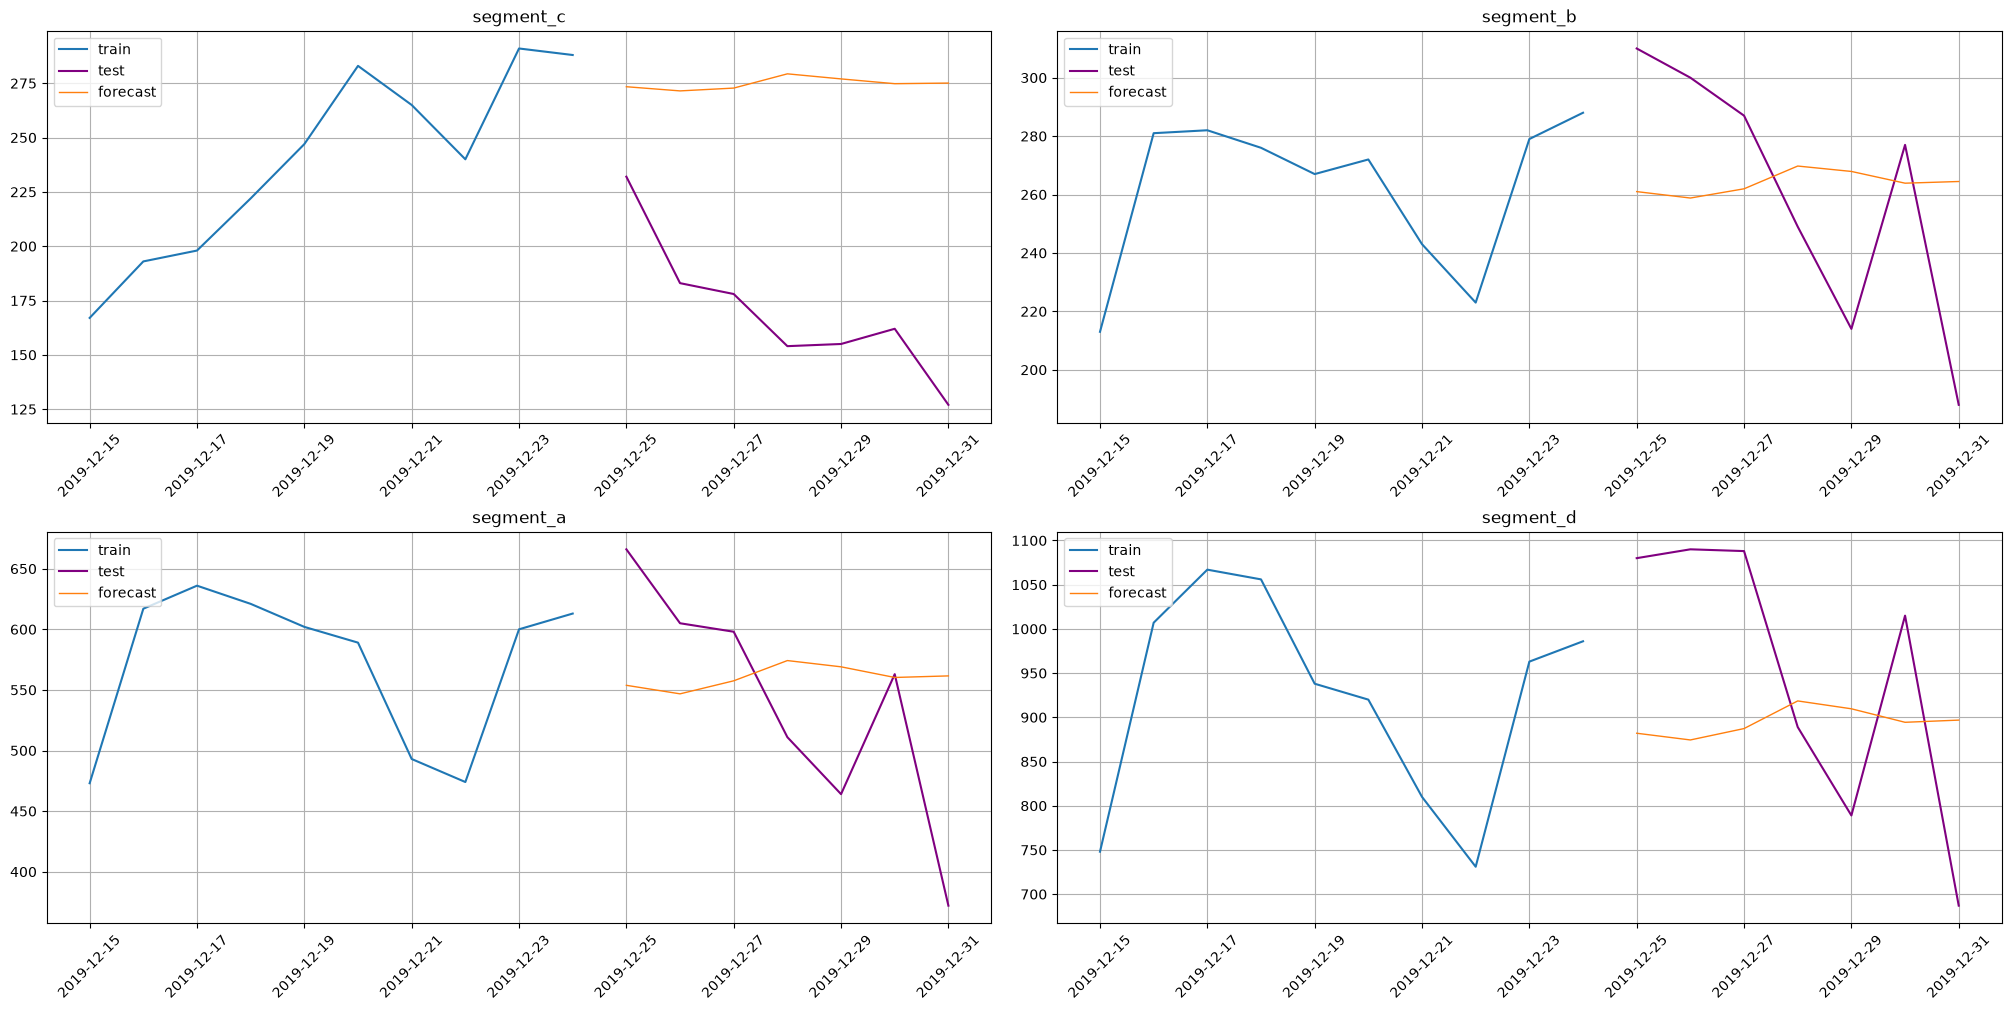

In [21]:
plot_forecast(
    train_ts=train_ts,
    test_ts=test_ts,
    forecast_ts=forecast_ts,
    n_train_samples=10
)